Student Details:

RA2311003010364 - Syed Asifa

RA2311003010365 - Anish Sethi

RA2311003010367 - Kritak Prasad


Real-World Problem Identification

Problem Statement

Smart assistants like Amazon Alexa and Google Assistant need to understand user queries accurately in order to provide correct responses.

However, users often give:

Ambiguous commands
Different phrasing for the same intent
Natural language variations

This creates a challenge in:

Correctly identifying user intent from text input

Load the dataset and show the basic features of the dataset

In [ ]:
import pandas as pd

df = pd.read_csv("data_full.csv")

# Basic inspection
print(df.head())
print(df.shape)
print(df.info())

                                                text  domain  intent  split
0               i would like to hear something funny       9     132   test
1            what ingredients are in antipasto salad       3      34  train
2                               roll five sided dice       7     104   test
3  is there enough money in my bank of hawaii for...       1      12  train
4          did i tell you to remind me about laundry       4      49   test
(23700, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23700 entries, 0 to 23699
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    23700 non-null  object
 1   domain  23700 non-null  int64 
 2   intent  23700 non-null  int64 
 3   split   23700 non-null  object
dtypes: int64(2), object(2)
memory usage: 740.8+ KB
None


PART 1: Data Collection

In [ ]:
# ==============================
# STEP 1: Import Libraries
# ==============================
import pandas as pd

# ==============================
# STEP 2: Load Dataset
# ==============================
df = pd.read_csv("data_full.csv")

# Display basic dataset info
print("Original Dataset")
display(df.head())
print("Shape:", df.shape)
print("\nInfo:")
print(df.info())


# ==============================
# STEP 3: Create Commands Table
# ==============================
commands = df.copy()
commands['id'] = range(1, len(commands)+1)

commands = commands[['id', 'text', 'intent']]

print("\nCommands Table")
display(commands.head())
print("Shape:", commands.shape)


# ==============================
# STEP 4: Create Intents Table
# ==============================
intents = df[['intent']].drop_duplicates().reset_index(drop=True)
intents['intent_id'] = range(1, len(intents)+1)

intents = intents[['intent_id', 'intent']]

print("\nIntents Table")
display(intents.head())
print("Shape:", intents.shape)


# ==============================
# STEP 5: Link Commands with Intents
# ==============================
commands = commands.merge(intents, on='intent')

print("\nCommands after merging with Intent IDs")
display(commands.head())


# ==============================
# STEP 6: Create Metadata Table
# ==============================
metadata = commands.copy()

metadata['text_length'] = metadata['text'].apply(len)
metadata['word_count'] = metadata['text'].apply(lambda x: len(x.split()))

metadata = metadata[['id', 'text_length', 'word_count']]

print("\nMetadata Table")
display(metadata.head())
print("Shape:", metadata.shape)


# ==============================
# STEP 7: Create Intent Frequency Table
# ==============================
intent_freq = df['intent'].value_counts().reset_index()
intent_freq.columns = ['intent', 'count']

print("\nIntent Frequency Table")
display(intent_freq.head())


# ==============================
# STEP 8: Create Domain Table
# ==============================
def categorize(intent):
    # Convert intent to string to allow 'in' operator.
    # Note: This will fix the TypeError, but the categorization logic
    # will only work if the string representation of the integer intent
    # happens to contain "bank", "travel", "flight", or "music", which is unlikely.
    # For meaningful categorization, 'intent' should ideally be a descriptive string
    # or mapped to one.
    intent_str = str(intent)
    if "bank" in intent_str:
        return "banking"
    elif "travel" in intent_str or "flight" in intent_str:
        return "travel"
    elif "music" in intent_str:
        return "entertainment"
    else:
        return "other"

domain_table = df.copy()
domain_table['domain'] = domain_table['intent'].apply(categorize)

domain_table = domain_table[['text', 'intent', 'domain']]

print("\nDomain Table")
display(domain_table.head())


# ==============================
# STEP 9: Final Summary
# ==============================
print("\n✅ Summary:")
print("Total Records:", len(df))
print("Total Unique Intents:", intents.shape[0])


🔹 Original Dataset


,text,domain,intent,split
0,i would like to hear something funny,9,132,test
1,what ingredients are in antipasto salad,3,34,train
2,roll five sided dice,7,104,test
3,is there enough money in my bank of hawaii for...,1,12,train
4,did i tell you to remind me about laundry,4,49,test


Shape: (23700, 4)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23700 entries, 0 to 23699
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    23700 non-null  object
 1   domain  23700 non-null  int64 
 2   intent  23700 non-null  int64 
 3   split   23700 non-null  object
dtypes: int64(2), object(2)
memory usage: 740.8+ KB
None

🔹 Commands Table


,id,text,intent
0,1,i would like to hear something funny,132
1,2,what ingredients are in antipasto salad,34
2,3,roll five sided dice,104
3,4,is there enough money in my bank of hawaii for...,12
4,5,did i tell you to remind me about laundry,49


Shape: (23700, 3)

🔹 Intents Table


...

Shape: (23700, 3)

🔹 Intent Frequency Table


,intent,count
0,0,1200
1,34,150
2,132,150
3,12,150
4,49,150



🔹 Domain Table


,text,intent,domain
0,i would like to hear something funny,132,other
1,what ingredients are in antipasto salad,34,other
2,roll five sided dice,104,other
3,is there enough money in my bank of hawaii for...,12,other
4,did i tell you to remind me about laundry,49,other



✅ Summary:
Total Records: 23700
Total Unique Intents: 151


Dataset Description

The dataset has approximately 23,700 records with the following columns:

text: user query
intent: user intention
domain: category of query
split: train/test data
Tables Created
1. Commands Table

Contains user queries and intents
Columns: id, text, intent

2. Intents Table

Contains unique intent labels
Columns: intent_id, intent

3. Metadata Table

Contains derived features
Columns: id, text_length, word_count

4. Domain Table

Groups data into categories
Column: domain

5. Split Table

Shows train/test distribution
Columns: split, count

Relationship Between Tables
Commands table is the main dataset
Intents table is linked using intent
Metadata is linked using id
Domain groups commands into categories
Split shows dataset distribution

PART 2: Data Wrangling & Cleaning

In [ ]:
# ==============================
# Import Libraries & Load Data
# ==============================
import pandas as pd

df = pd.read_csv("data_full.csv")

# ==============================
# 1. Handling Missing Values
# ==============================
print("Missing Values BEFORE:")
print(df.isnull().sum())

df = df.dropna()

print("\nMissing Values AFTER:")
print(df.isnull().sum())


# ==============================
# 2. Removing Duplicates
# ==============================
print("\nDuplicates BEFORE:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicates AFTER:", df.duplicated().sum())


# ==============================
# 3. Data Type Conversion
# ==============================
print("\nData Types BEFORE:")
print(df.dtypes)

df['intent'] = df['intent'].astype(str)
df['domain'] = df['domain'].astype(str)

print("\nData Types AFTER:")
print(df.dtypes)


# ==============================
# 4. String Cleaning
# ==============================
print("\nText BEFORE Cleaning:")
print(df['text'].head())

df['text'] = df['text'].str.lower().str.strip()

print("\nText AFTER Cleaning:")
print(df['text'].head())


# ==============================
# 5. Merging Datasets
# ==============================
intents = df[['intent']].drop_duplicates().reset_index(drop=True)
intents['intent_id'] = range(1, len(intents)+1)

print("\nIntents Table BEFORE Merge:")
print(intents.head())

merged_df = df.merge(intents, on='intent')

print("\nData AFTER Merge:")
print(merged_df.head())


# ==============================
# 6. Filtering and Sorting
# ==============================
print("\nData BEFORE Filtering:")
print(df.head())

filtered_df = df[df['domain'] == '1'].sort_values(by='text')

print("\nData AFTER Filtering & Sorting:")
print(filtered_df.head())

Missing Values BEFORE:
text      0
domain    0
intent    0
split     0
dtype: int64

Missing Values AFTER:
text      0
domain    0
intent    0
split     0
dtype: int64

Duplicates BEFORE: 0
Duplicates AFTER: 0

Data Types BEFORE:
text      object
domain     int64
intent     int64
split     object
dtype: object

Data Types AFTER:
text      object
domain    object
intent    object
split     object
dtype: object

Text BEFORE Cleaning:
0                 i would like to hear something funny
1              what ingredients are in antipasto salad
2                                 roll five sided dice
3    is there enough money in my bank of hawaii for...
4            did i tell you to remind me about laundry
Name: text, dtype: object

Text AFTER Cleaning:
0                 i would like to hear something funny
1              what ingredients are in antipasto salad
2                                 roll five sided dice
3    is there enough money in my bank of hawaii for...
4            did i te

Missing Values: Removed to avoid errors and inaccurate results

Duplicates: Removed to prevent bias

Data Types: Converted for consistency

String Cleaning: Standardized text format

Merging: Combined related data for better analysis

Filtering & Sorting: Organized data for focused insights

PART 3: Data Preparation & Analysis

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("data_full.csv")

# Create numerical features
df['text_length'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

# -----------------------------
# 1. Data Summarization
# -----------------------------
print("Statistical Measures:")
print(df[['text_length', 'word_count']].describe())

print("\nMedian Values:")
print(df[['text_length', 'word_count']].median())

# Group-based analysis
group_analysis = df.groupby('domain')[['text_length', 'word_count']].mean()
print("\nGroup-based Analysis:")
print(group_analysis)


# -----------------------------
# 2. Standardization (Z-score)
# -----------------------------
scaler = StandardScaler()
df[['scaled_length', 'scaled_words']] = scaler.fit_transform(df[['text_length', 'word_count']])

print("\nAfter Scaling:")
print(df[['scaled_length', 'scaled_words']].head())


# -----------------------------
# 3. Outlier Detection (IQR)
# -----------------------------
Q1 = df['text_length'].quantile(0.25)
Q3 = df['text_length'].quantile(0.75)
IQR = Q3 - Q1

print("\nBefore Removing Outliers:", df.shape)

# Remove outliers
df_clean = df[
    (df['text_length'] >= Q1 - 1.5 * IQR) &
    (df['text_length'] <= Q3 + 1.5 * IQR)
]

print("After Removing Outliers:", df_clean.shape)

Statistical Measures:
        text_length    word_count
count  23700.000000  23700.000000
mean      39.932827      8.315359
std       15.501631      3.220028
min        2.000000      1.000000
25%       29.000000      6.000000
50%       38.000000      8.000000
75%       49.000000     10.000000
max      136.000000     28.000000

Median Values:
text_length    38.0
word_count      8.0
dtype: float64

Group-based Analysis:
        text_length  word_count
domain                         
0         42.875000    8.473333
1         45.933333    9.342667
2         45.995111    9.620000
3         45.212000    8.906222
4         39.329778    8.258222
5         42.754667    9.431111
6         49.836000   10.228444
7         31.233778    6.701333
8         40.191556    8.603111
9         29.338667    6.256889
10        27.934222    5.721333

After Scaling:
   scaled_length  scaled_words
0      -0.253709     -0.408502
1      -0.060177     -0.719064
2      -1.285881     -1.340190
3       0.971994      

1. Data Summarization

Statistical measures like mean and median were calculated to understand data distribution.
Group-based analysis was performed using domain to identify patterns across categories.

2. Standardization

Z-score scaling was applied to normalize numerical features.

Reason:
Scaling ensures all features are on the same scale, improving analysis and model performance.

3. Outlier Detection and Removal

Outliers were detected using the IQR method and removed.

Reason:
Outliers can distort results, so removing them improves accuracy.

Comparison:
Dataset size was compared before and after removal to observe impact.

PART 4: Visualization using Matplotlib

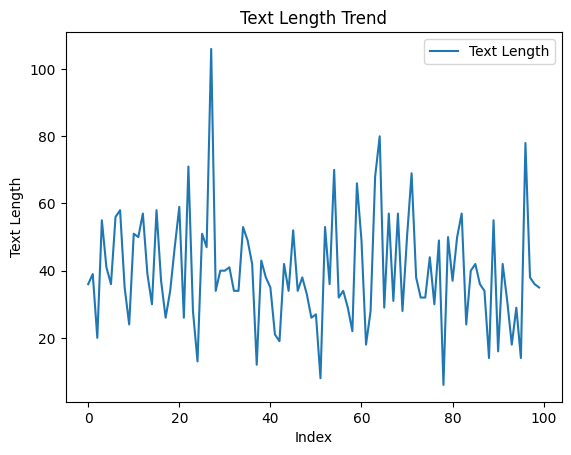

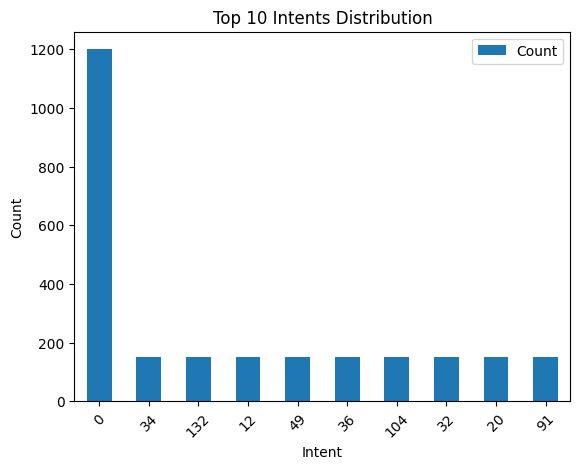

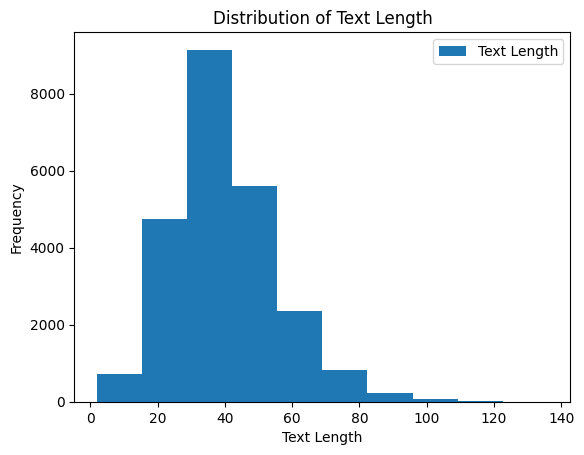

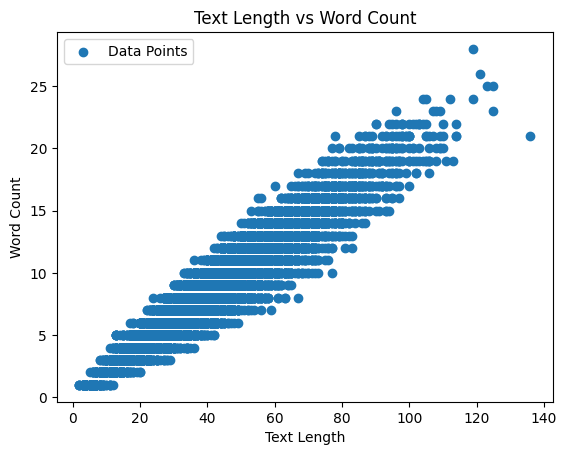

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data_full.csv")

# Create numerical features
df['text_length'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

# -----------------------------
# 1. Line Plot
# -----------------------------
plt.figure()
plt.plot(df['text_length'].head(100))
plt.title("Text Length Trend")
plt.xlabel("Index")
plt.ylabel("Text Length")
plt.legend(["Text Length"])
plt.show()


# -----------------------------
# 2. Bar Plot
# -----------------------------
intent_counts = df['intent'].value_counts().head(10)

plt.figure()
intent_counts.plot(kind='bar')
plt.title("Top 10 Intents Distribution")
plt.xlabel("Intent")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(["Count"])
plt.show()


# -----------------------------
# 3. Histogram
# -----------------------------
plt.figure()
plt.hist(df['text_length'])
plt.title("Distribution of Text Length")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.legend(["Text Length"])
plt.show()


# -----------------------------
# 4. Scatter Plot
# -----------------------------
plt.figure()
plt.scatter(df['text_length'], df['word_count'])
plt.title("Text Length vs Word Count")
plt.xlabel("Text Length")
plt.ylabel("Word Count")
plt.legend(["Data Points"])
plt.show()

Line Plot: Shows trend of text length

Bar Plot: Displays frequency of top intents

Histogram: Shows distribution of text length

Scatter Plot: Shows relationship between text length and word count

PART 5: Visualization using Seaborn

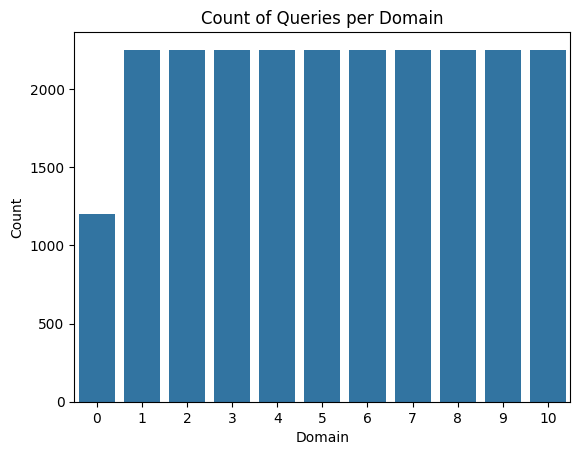

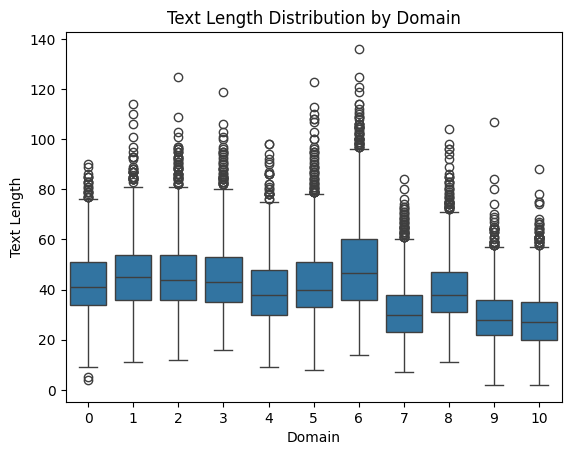

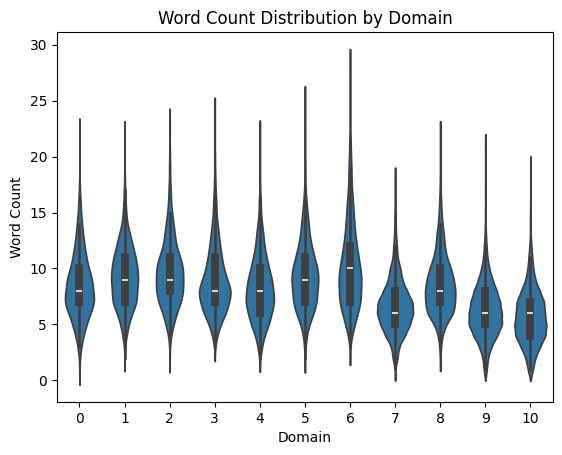

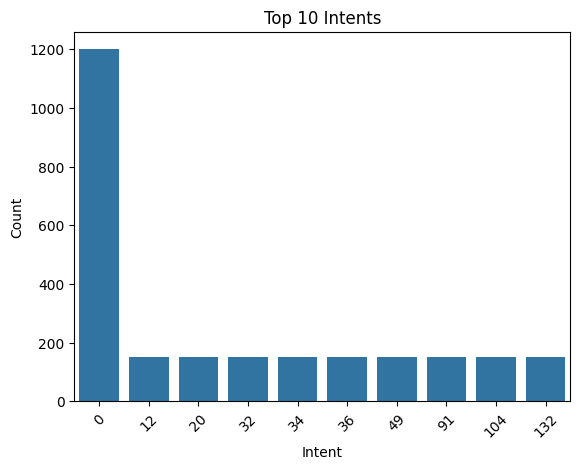

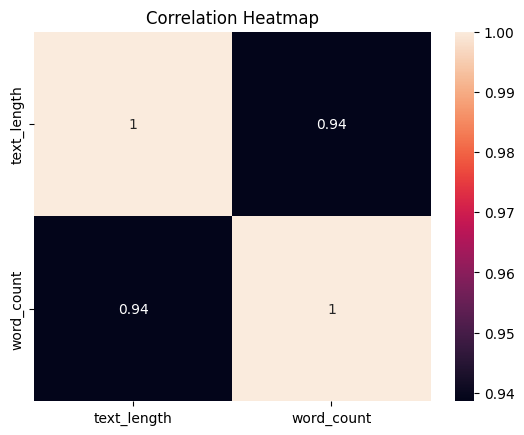

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("data_full.csv")

# Create numerical features
df['text_length'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

# -----------------------------
# 1. Countplot
# -----------------------------
plt.figure()
sns.countplot(x='domain', data=df)
plt.title("Count of Queries per Domain")
plt.xlabel("Domain")
plt.ylabel("Count")
plt.show()


# -----------------------------
# 2. Boxplot
# -----------------------------
plt.figure()
sns.boxplot(x='domain', y='text_length', data=df)
plt.title("Text Length Distribution by Domain")
plt.xlabel("Domain")
plt.ylabel("Text Length")
plt.show()


# -----------------------------
# 3. Violin Plot
# -----------------------------
plt.figure()
sns.violinplot(x='domain', y='word_count', data=df)
plt.title("Word Count Distribution by Domain")
plt.xlabel("Domain")
plt.ylabel("Word Count")
plt.show()


# -----------------------------
# 4. Barplot
# -----------------------------
intent_counts = df['intent'].value_counts().head(10).reset_index()
intent_counts.columns = ['intent', 'count']

plt.figure()
sns.barplot(x='intent', y='count', data=intent_counts)
plt.title("Top 10 Intents")
plt.xlabel("Intent")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


# -----------------------------
# 5. Heatmap
# -----------------------------
plt.figure()
corr = df[['text_length', 'word_count']].corr()
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

Countplot: Shows how queries are distributed across domains

Boxplot: Displays variation and outliers in text length

Violin Plot: Shows distribution and density of word count

Barplot: Highlights most frequent intents

Heatmap: Shows correlation between text length and word count

PART 6: Insights & Conclusion

Key Findings

The dataset contains a large number of user queries distributed across multiple domains and intents

Text length and word count vary across different types of queries

Certain intents appear more frequently, showing imbalance in the dataset

Insights

Most user queries are concentrated in a few domains, indicating uneven distribution

There is a strong relationship between text length and word count

Some queries have extreme lengths, which can act as outliers and affect analysis

Improvements and Future Scope

Apply machine learning models for intent prediction

Include more diverse and balanced data across all domains

Extend the system to support real-time voice input and multilingual queries

Graphs for the ppt

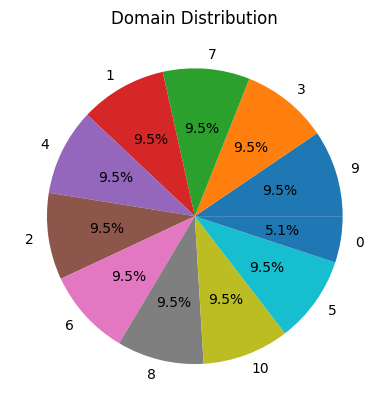

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data_full.csv")

# Count domain values
domain_counts = df['domain'].value_counts()

# Plot pie chart
plt.figure()
plt.pie(domain_counts, labels=domain_counts.index, autopct='%1.1f%%')
plt.title("Domain Distribution")
plt.show()

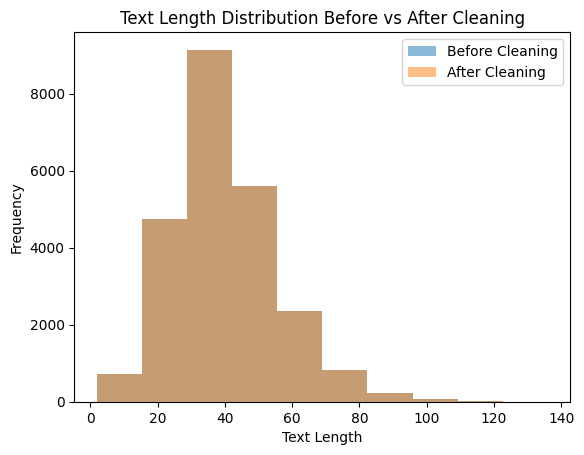

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data_full.csv")

# BEFORE cleaning
df['text_length'] = df['text'].apply(len)

# AFTER cleaning
df_clean = df.copy()
df_clean['text'] = df_clean['text'].str.lower().str.strip()

# Plot both together
plt.figure()
plt.hist(df['text_length'], alpha=0.5, label='Before Cleaning')
plt.hist(df_clean['text_length'], alpha=0.5, label='After Cleaning')

plt.title("Text Length Distribution Before vs After Cleaning")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.legend()
plt.show()

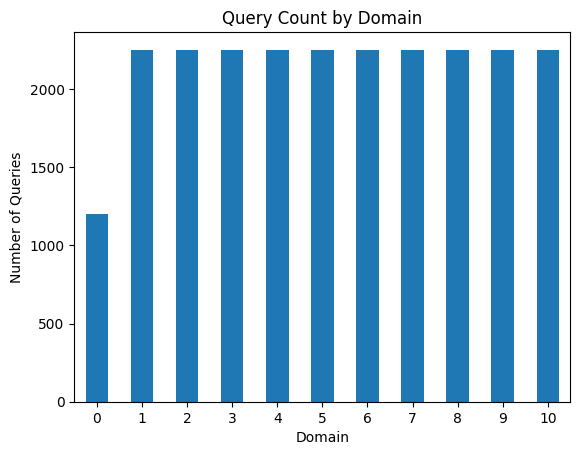

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data_full.csv")

# Count queries per domain
domain_counts = df['domain'].value_counts().sort_index()

# Plot
plt.figure()
domain_counts.plot(kind='bar')
plt.title("Query Count by Domain")
plt.xlabel("Domain")
plt.ylabel("Number of Queries")
plt.xticks(rotation=0)
plt.show()

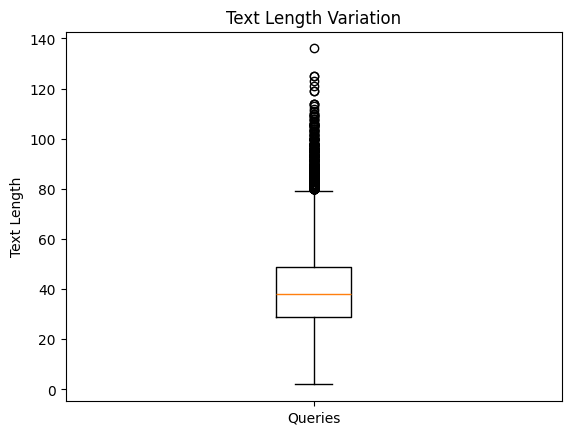

In [ ]:
# Create text length feature
df['text_length'] = df['text'].apply(len)

# Plot
plt.figure()
plt.boxplot(df['text_length'])
plt.title("Text Length Variation")
plt.ylabel("Text Length")
plt.xticks([1], ["Queries"])
plt.show()

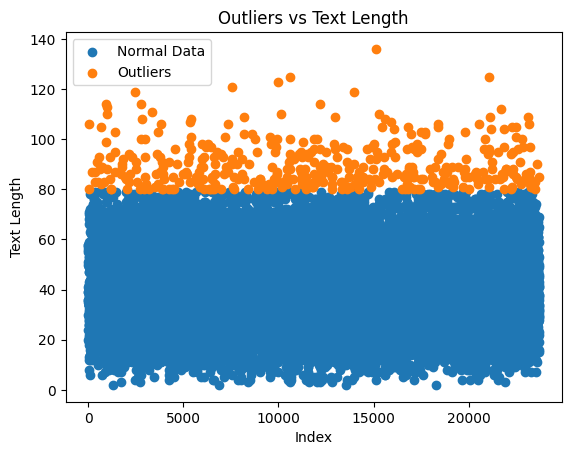

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data_full.csv")

# Create text length
df['text_length'] = df['text'].apply(len)

# Calculate IQR
Q1 = df['text_length'].quantile(0.25)
Q3 = df['text_length'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Separate normal and outliers
normal = df[(df['text_length'] >= lower_bound) & (df['text_length'] <= upper_bound)]
outliers = df[(df['text_length'] < lower_bound) | (df['text_length'] > upper_bound)]

# Plot
plt.figure()
plt.scatter(normal.index, normal['text_length'], label='Normal Data')
plt.scatter(outliers.index, outliers['text_length'], label='Outliers')

plt.title("Outliers vs Text Length")
plt.xlabel("Index")
plt.ylabel("Text Length")
plt.legend()
plt.show()